### Miguel Baños Baladrón
### Miguel Pérez Francos
### Rodrigo Touceda Tapias


# Proyecto de investigación: Reconocimiento de Actividades Humanas (HAR) con Sensores Inerciales

# Importaciones

In [21]:
# Incluimos scrips necesarios
include("setup.jl")
include("helpers.jl")
include("wrappers.jl")

# Usamos JLD2 para recuperar el estado exacto del preprocesamiento.
if isfile("datos_procesados.jld2")
    JLD2.@load "datos_procesados.jld2" df_trainval df_test X_trainval y_trainval folds_trainval
    println("Datos cargados correctamente.")
else
    error("No se encontró 'datos_procesados.jld2'. Ejecuta primero Preprocess.ipynb.")
end

# Limpiamos entrenamiento
X_trainval = disallowmissing(X_trainval)

# Preparamos test
y_test = df_test.Activity

# Seleccionamos las columnas y limpiamos
X_test_dirty = DataFrames.select(df_test, Not([:subject, :Activity]))
X_test = disallowmissing(X_test_dirty)
allowmissing!(df_test)
df_test = disallowmissing(df_test)

println("Tipos corregidos: X_test ya no admite missings.")

Entorno cargado correctamente
Entorno cargado correctamente
Datos cargados correctamente.
Tipos corregidos: X_test ya no admite missings.


# Función para ejecutar modelos

### Esta función tiene como objetivo sistematizar la evaluación de combinaciones entre técnias de selección de características, reducción de dimensionalidad y clasificadores:
- ### Para que cada técnica aparezca al menos una vez, calculamos el número máximo de iteraciones (usando la lista de los modelos, la más larga) y se asignan filtros y reducciones de forma cíclica.
- ### Es reproducible, ya que convierte los diccionarios en listas ordenadas alfabéticamente.
- ### Añadimos una lógica de checkpoint, para que en caso de que la ejecución se detenga antes de terminar, la reanude desde el error, en vez de volver a empezar. Guardamos las métricas en un CSV.
- ### Extraemos accuracy, f1_score, balanced_accuracy media y por cada fold.

In [22]:
function run_models(dic_filtros, dic_reducciones, dic_modelos, output_file; 
                    X=X_trainval, y=y_trainval, folds=folds_trainval)
    
    # Convierte diccionarios a listas ordenadas para ejecución determinista
    list_filtros     = sort(collect(dic_filtros), by=x->x[1])
    list_reducciones = sort(collect(dic_reducciones), by=x->x[1])
    list_modelos     = sort(collect(dic_modelos), by=x->x[1])

    # Calcula longitud de cada lista de opciones
    n_filtros = length(list_filtros)
    n_reducciones = length(list_reducciones)
    n_modelos = length(list_modelos)

    # Define el número máximo de iteraciones para cubrir todas las técnicas
    max_iter = max(n_filtros, n_reducciones, n_modelos)
    
    # Comprueba si existe archivo previo para reanudar o iniciar de cero
    if isfile(output_file)
        results_df = CSV.read(output_file, DataFrame)
        # Crea conjunto de identificadores para evitar repetir experimentos
        combinaciones_hechas = Set([
            (string(r.Filter), string(r.Reduction), string(r.Model)) 
            for r in eachrow(results_df)
        ])
    else
        # Inicializa DataFrame vacío con las columnas de métricas
        results_df = DataFrame(
            Filter = String[], Reduction = String[], Model = String[],
            Accuracy_Mean = Float64[], 
            F1_Score = Float64[], 
            B_Accuracy_mean = Float64[],
            B_accuracy_list = String[]
        )
        combinaciones_hechas = Set{Tuple{String, String, String}}()
    end
    
    # Define métricas: Accuracy, F1 y Balanced Accuracy
    measures = [accuracy, multiclass_f1score, balanced_accuracy]

    println("Iniciando ejecución: $max_iter experimentos totales.")

    # Bucle principal iterando cíclicamente
    for i in 1:max_iter
        # Selección modular de componentes para cubrir todas las opciones
        pair_filt = list_filtros[(i - 1) % n_filtros + 1]
        pair_red  = list_reducciones[(i - 1) % n_reducciones + 1]
        pair_mod  = list_modelos[(i - 1) % n_modelos + 1]

        # Desempaqueta nombres y objetos
        filt_name, filt_model = pair_filt
        red_name, red_model   = pair_red
        mod_name, mod_model   = pair_mod

        # Salta iteración si la combinación ya existe
        if (filt_name, red_name, mod_name) in combinaciones_hechas
            continue 
        end

        println("\nEvaluando ($i/$max_iter): [$filt_name] + [$red_name] + [$mod_name]")
        
        # Construye el pipeline con las técnicas seleccionadas
        pipe = PersonalizedPipeline(
            scaler    = MyMinMaxScaler(), 
            filter    = filt_model,      
            reduction = red_model,       
            clf       = mod_model        
        )
        
        try
            # Instancia la 'machine' de MLJ y ejecuta evaluación
            mach = machine(pipe, X, y) 
            evaluation = evaluate!(
                mach, 
                resampling = folds, 
                measures = measures, 
                verbosity = 0,
                acceleration = CPUThreads() 
            )
            
            # Extrae medias de las métricas
            acc_mean = evaluation.measurement[1]
            f1_mean   = evaluation.measurement[2]
            b_acc_mean   = evaluation.measurement[3]
            
            # Obtiene lista de Balanced Accuracy por fold y serializa a string
            b_acc_folds = evaluation.per_fold[3]
            b_acc_str = join(round.(b_acc_folds, digits=5), ";")

            println("Acc: $(round(acc_mean, digits=4)) | F1: $(round(f1_mean, digits=4)) | B_acc: $(round(b_acc_mean, digits=4))")
            
            # Guarda resultados en DataFrame y actualiza CSV
            push!(results_df, (filt_name, red_name, mod_name, acc_mean, f1_mean, b_acc_mean, b_acc_str), promote=true)
            CSV.write(output_file, results_df)
            
        catch e
            # Captura errores para no detener el flujo y registra fallo
            println("ERROR en $filt_name + $red_name + $mod_name: $e")
            push!(results_df, (filt_name, red_name, mod_name, NaN, NaN, NaN, "ERROR"))
            CSV.write(output_file, results_df)
        end
        
        # Libera memoria tras cada iteración
        GC.gc()
    end
    
    println("Experimento finalizado.")
    return results_df
end;

# Definición de los diccionarios para los modelos básicos y selección de atributos

In [23]:
# Diccionarios de los filtrados
dic_filtros = Dict(
    "Sin_Filtrado" => nothing,
    "ANOVA" => MyANOVAFilter(n_features=N_FEATURES),
    "Pearson" => MyPearsonFilter(n_features=N_FEATURES),
    "Spearman" => MySpearmanFilter(n_features=N_FEATURES),
    "Kendall" => MyKendallFilter(n_features=N_FEATURES),
    "MI" => MyMIFilter(n_features=N_FEATURES),
    "RFE" => MyRFEFilter(n_features=N_FEATURES)
)

# Diccionarios de las reducciones de dimensionalidad
dic_reducciones = Dict(
    "Sin reducción" => IdentityTransformer(),
    "PCA" => PCA(variance_ratio=0.95), # Conservar el 95% de la varianza
    "ICA" => ICA(outdim=2, maxiter=10000,tol=0.5), # Tolerancia alta para evitar error
    "LDA" => LDA(method=:whiten, outdim=5) # En LDA, la dimensión es n_classes - 1
)

# Diccionarios de modelos
dic_modelos = Dict(
    # MLP
    "NeuralNetwork_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
    "NeuralNetwork_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
    "NeuralNetwork_100_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))),
    
    # KNN
    "KNN_1" => KNNClassifier(K=1),
    "KNN_10" => KNNClassifier(K=10),
    "KNN_20" => KNNClassifier(K=20),

    # SVM
    "SVM_0.1" => ProbabilisticSVC(cost=0.1),
    "SVM_0.5" => ProbabilisticSVC(cost=0.5),
    "SVM_1.0" => ProbabilisticSVC(cost=1.0)
);

In [24]:
# Ejecutar y guardar
df_resultados_basicos = run_models(
    dic_filtros, 
    dic_reducciones, 
    dic_modelos, 
    "resultados_modelos_basicos.csv"
)

Iniciando ejecución: 9 experimentos totales.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String31,Float64,Float64,Float64,String
1,ANOVA,ICA,KNN_1,0.591744,0.590583,0.590066,0.62677;0.55199;0.61759;0.57407;0.5792
2,Kendall,LDA,KNN_10,0.957523,0.957549,0.957705,0.96633;0.94923;0.95082;0.94778;0.97424
3,MI,PCA,KNN_20,0.894079,0.893302,0.893082,0.89989;0.87871;0.89793;0.91762;0.87073
4,Pearson,Sin reducción,NeuralNetwork_100,0.893753,0.890863,0.892993,0.9291;0.84141;0.88771;0.86468;0.94273
5,RFE,ICA,NeuralNetwork_100_50,0.586312,0.550403,0.584556,0.58401;0.56956;0.5786;0.53971;0.65389
6,Sin_Filtrado,LDA,NeuralNetwork_50,0.889517,0.885942,0.893031,0.89364;0.91274;0.90341;0.91095;0.84206
7,Spearman,PCA,SVM_0.1,0.910483,0.909962,0.910647,0.9292;0.89265;0.92234;0.9105;0.89776
8,ANOVA,Sin reducción,SVM_0.5,0.933732,0.933374,0.933782,0.9595;0.91366;0.93447;0.92812;0.93167
9,Kendall,ICA,SVM_1.0,0.670831,0.66181,0.669607,0.67827;0.67086;0.69487;0.66097;0.64239


# Definición de los diccionarios de los modelos de ensemble (Primer Experimento)

### Para la parte de ensembles, reciclamos la función run_models y usamos la misma idea, definir diccionarios de filtrados (tenemos que indicar que no hay), reducciones (solo PCA 95% o sin) y modelos. El apartado de modelos esta vez se ha centrado en pruebas de Bagging y Boosting.
### En el caso de AdaBoost, usamos AdaBoostStumpClassifier que a diferencia de usar SVM como base, usa Decission Stumps (Decission Trees de profundidad 1). Como son aprendices débiles, ejecutamos varios modelos para encontrar un número de iteraciones óptimo. Hasta las 300 iteraciones obtuvimos mejoría, pero en las 400, empeoraron las métricas, mostrando overfitting.

In [25]:
# No se especifica usar ningún filtrado para ensembles, debemos decirle a nuestra función que no hay
dic_filtros_ensemble = Dict(
    "Sin_Filtrado" => nothing
)

# Usamos PCA con el 95% de la varianza o ninguno
dic_reducciones_ensemble = Dict(
    "Sin_Reduccion" => IdentityTransformer(), 
    "PCA_95"        => PCA(variance_ratio=0.95)
)

# Definición del knn base para Bagging
knn_base = KNNClassifier(K=5)

# Diccionario de los modelos de ensemble
dic_modelos_ensemble = Dict(
    # BaggingClassifier
    "Bagging_KNN_10" => EnsembleModel(model = knn_base, n = 10),
    "Bagging_KNN_50" => EnsembleModel(model = knn_base, n = 50),

    # AdaBoost
    "AdaBoost" => AdaBoostStumpClassifier(n_iter = 100),
    "AdaBoost200" => AdaBoostStumpClassifier(n_iter = 200),
    "AdaBoost300" => AdaBoostStumpClassifier(n_iter = 300),
    "AdaBoost400" => AdaBoostStumpClassifier(n_iter = 400),

    # EvoTree
    "EvoTree_50" => EvoTreeClassifier(nrounds = 50, eta = 0.2),
    "EvoTree_100" => EvoTreeClassifier(nrounds = 100, eta = 0.2)
);

In [26]:
df_resultados_ensembles = run_models(
    dic_filtros_ensemble, 
    dic_reducciones_ensemble, 
    dic_modelos_ensemble, 
    "resultados_modelos_ensemble.csv"
)

Iniciando ejecución: 8 experimentos totales.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String15,Float64,Float64,Float64,String
1,Sin_Filtrado,PCA_95,AdaBoost,0.678979,0.660709,0.680322,0.69891;0.66974;0.65539;0.73831;0.6353
2,Sin_Filtrado,Sin_Reduccion,AdaBoost200,0.686475,0.622646,0.683848,0.69959;0.74708;0.74516;0.56501;0.6598
3,Sin_Filtrado,PCA_95,AdaBoost300,0.717545,0.708043,0.718855,0.69365;0.73162;0.72019;0.77213;0.67699
4,Sin_Filtrado,Sin_Reduccion,AdaBoost400,0.693862,0.645679,0.697611,0.68637;0.75629;0.7776;0.57012;0.69961
5,Sin_Filtrado,PCA_95,Bagging_KNN_10,0.887452,0.885775,0.885976,0.88429;0.88673;0.88089;0.91101;0.86613
6,Sin_Filtrado,Sin_Reduccion,Bagging_KNN_50,0.895817,0.894281,0.89416,0.89915;0.88716;0.88855;0.92028;0.87459
7,Sin_Filtrado,PCA_95,EvoTree_100,0.881477,0.877813,0.878653,0.90069;0.87467;0.89897;0.88948;0.82665
8,Sin_Filtrado,Sin_Reduccion,EvoTree_50,0.918197,0.916742,0.917156,0.94231;0.88292;0.91685;0.91872;0.92454


# Evaluación final sobre el conjunto de test

In [27]:
# Unificamos diccionarios
all_filtros     = merge(dic_filtros, dic_filtros_ensemble)
all_reducciones = merge(dic_reducciones, dic_reducciones_ensemble)
all_modelos     = merge(dic_modelos, dic_modelos_ensemble);

In [28]:
# Mejor KNN
best_knn = get_better("KNN", "resultados_modelos_basicos.csv")

# Mejor SVM
best_svm = get_better("SVM", "resultados_modelos_basicos.csv")

# Mejor MLP 
best_mlp = get_better("NeuralNetwork", "resultados_modelos_basicos.csv")

# Mejor Bagging 
best_bagging = get_better("Bagging", "resultados_modelos_ensemble.csv")

# Mejor AdaBoost
best_adaboost = get_better("AdaBoost", "resultados_modelos_ensemble.csv")

# Mejor EvoTree
best_evotree = get_better("EvoTree", "resultados_modelos_ensemble.csv");

Mejor KNN encontrado:
Config: Kendall + LDA + KNN_10
-> B_Accuracy_mean: 0.9577

Mejor SVM encontrado:
Config: ANOVA + Sin reducción + SVM_0.5
-> B_Accuracy_mean: 0.9338

Mejor NeuralNetwork encontrado:
Config: Sin_Filtrado + LDA + NeuralNetwork_50
-> B_Accuracy_mean: 0.893

Mejor Bagging encontrado:
Config: Sin_Filtrado + Sin_Reduccion + Bagging_KNN_50
-> B_Accuracy_mean: 0.8942

Mejor AdaBoost encontrado:
Config: Sin_Filtrado + PCA_95 + AdaBoost300
-> B_Accuracy_mean: 0.7189

Mejor EvoTree encontrado:
Config: Sin_Filtrado + Sin_Reduccion + EvoTree_50
-> B_Accuracy_mean: 0.9172



In [29]:
# Agrupamos los mejores modelos encontrados en un diccionario
mejores_modelos = Dict(
    "SVM (Best)" => best_svm,
    "KNN (Best)" => best_knn,
    "MLP (Best)" => best_mlp,
    "Bagging (Best)" => best_bagging,
    "AdaBoost (Best)" => best_adaboost,
    "EvoTree (Best)" => best_evotree
)

# Archivos de salida
output_file_test = "resultados_finales_test.csv"
output_matrices_test = "matrices_conf_test.jld2"

# Cargar CSV
if isfile(output_file_test)
    println("=== Archivo CSV detectado. Cargando resultados previos ===")
    resultados_test = CSV.read(output_file_test, DataFrame)
    resultados_test.Modelo = string.(resultados_test.Modelo)
    modelos_ya_calculados = Set(resultados_test.Modelo)
else
    println("=== No se encontró CSV previo. Creando nueva tabla ===")
    resultados_test = DataFrame(Modelo=String[], Accuracy=Float64[], F1_Score=Float64[], B_Accuracy=Float64[])
    modelos_ya_calculados = Set{String}()
end

# Cargar Matrices de Confusión
if isfile(output_matrices_test)
    JLD2.@load output_matrices_test dic_matrices_test
    println("=== Matrices de confusión previas cargadas. ===")
else
    dic_matrices_test = Dict()
end

println("\n=== Iniciando Evaluación Final en TEST ===")

for (nombre, pipeline) in mejores_modelos
    
    # Checkpoint
    if (nombre in modelos_ya_calculados) && (haskey(dic_matrices_test, nombre))
        println("-> Saltando: $nombre (Ya existe en CSV y Diccionario)")
        continue 
    end

    println("Procesando: $nombre ...")

    # Creamos la machine
    mach = machine(pipeline, X_trainval, y_trainval)
    
    # Entrenamos
    fit!(mach, verbosity=0)
    
    # Evaluamos con test
    y_pred = predict_mode(mach, X_test)
    
    # Calculamos métricas
    acc   = accuracy(y_pred, y_test)
    f1    = multiclass_f1score(y_pred, y_test)
    b_acc = balanced_accuracy(y_pred, y_test)
    
    # Guardamos métricas en DataFrame y CSV
    if !(nombre in modelos_ya_calculados)
        push!(resultados_test, (nombre, acc, f1, b_acc))
        CSV.write(output_file_test, resultados_test)
    end
    
    # Guardamos Matriz en Diccionario y JLD2
    cm = confusion_matrix(y_pred, y_test)
    dic_matrices_test[nombre] = cm
    @save output_matrices_test dic_matrices_test # Guardado incremental
    
end

println("\nProceso completado.")
println("Métricas guardadas en: $output_file_test")
println("Matrices guardadas en: $output_matrices_test")

# Mostrar tabla resumen
println("\nResultados Finales en Test:")
resultados_test

=== Archivo CSV detectado. Cargando resultados previos ===
=== Matrices de confusión previas cargadas. ===

=== Iniciando Evaluación Final en TEST ===
-> Saltando: SVM (Best) (Ya existe en CSV y Diccionario)
-> Saltando: AdaBoost (Best) (Ya existe en CSV y Diccionario)
-> Saltando: EvoTree (Best) (Ya existe en CSV y Diccionario)
-> Saltando: KNN (Best) (Ya existe en CSV y Diccionario)
-> Saltando: MLP (Best) (Ya existe en CSV y Diccionario)
-> Saltando: Bagging (Best) (Ya existe en CSV y Diccionario)

Proceso completado.
Métricas guardadas en: resultados_finales_test.csv
Matrices guardadas en: matrices_conf_test.jld2

Resultados Finales en Test:


Row,Modelo,Accuracy,F1_Score,B_Accuracy
,String15,Float64,Float64,Float64
1,SVM (Best),0.902194,0.878588,0.885348
2,AdaBoost (Best),0.738574,0.706983,0.720158
3,EvoTree (Best),0.865631,0.843422,0.850692
4,KNN (Best),0.956124,0.950527,0.949871
5,MLP (Best),0.936929,0.931995,0.930312
6,Bagging (Best),0.875686,0.84901,0.859283


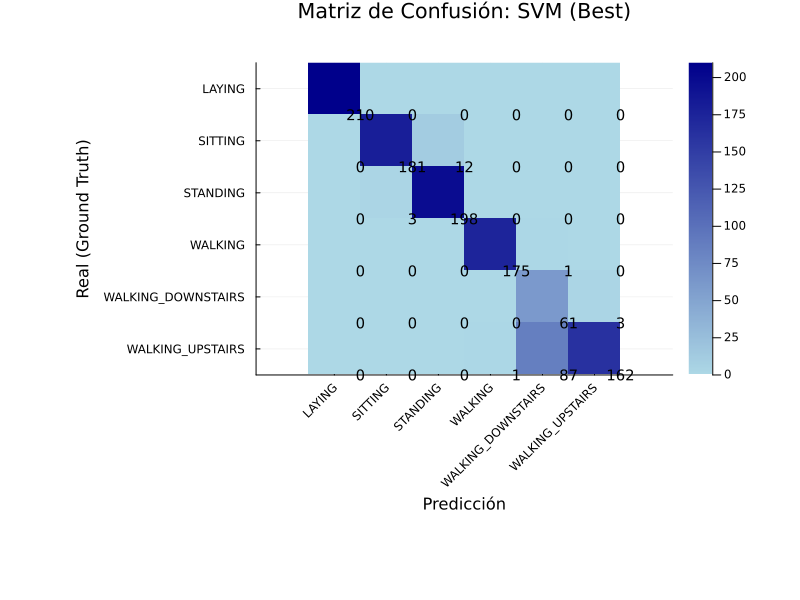

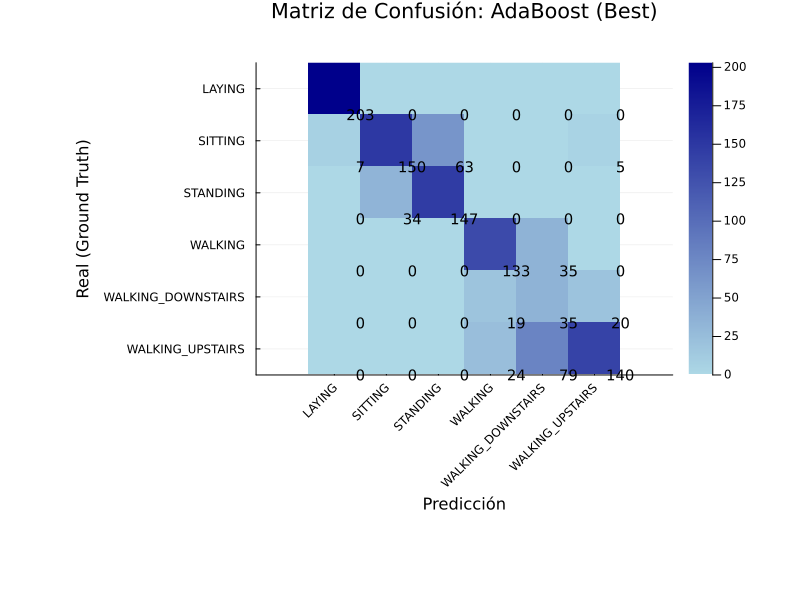

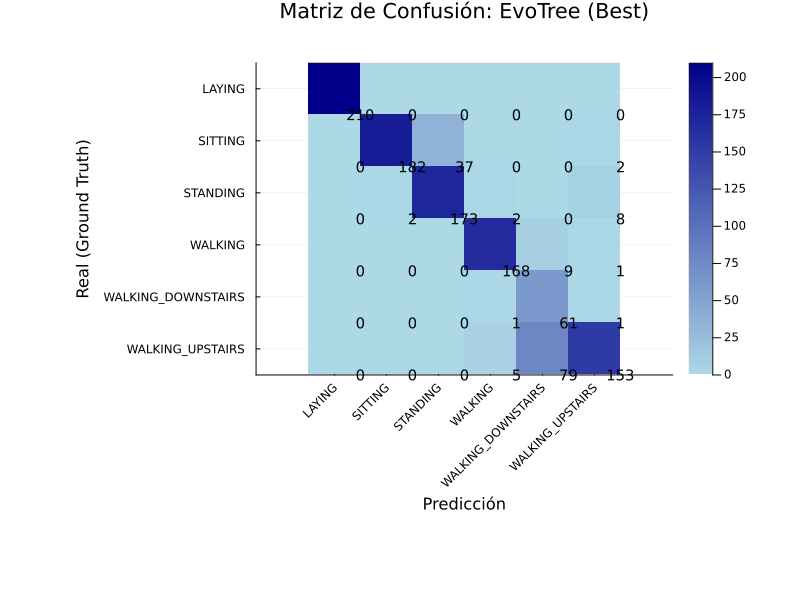

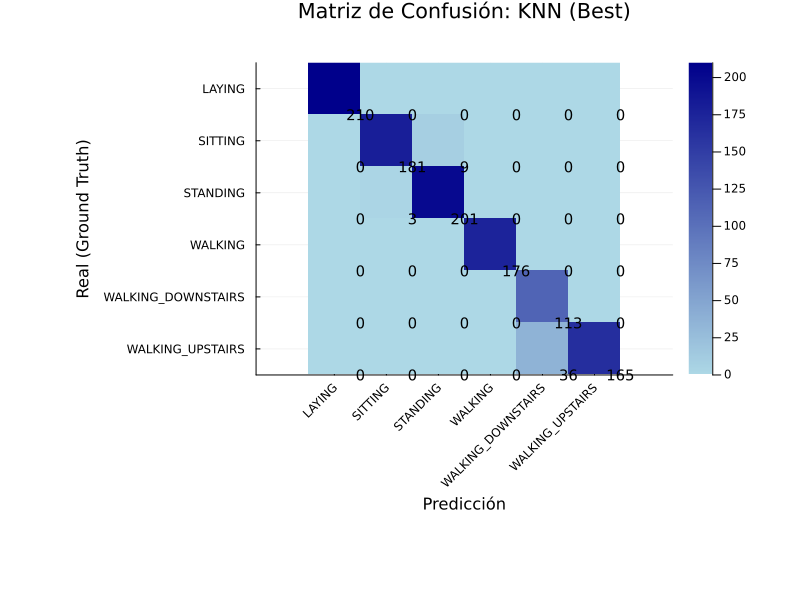

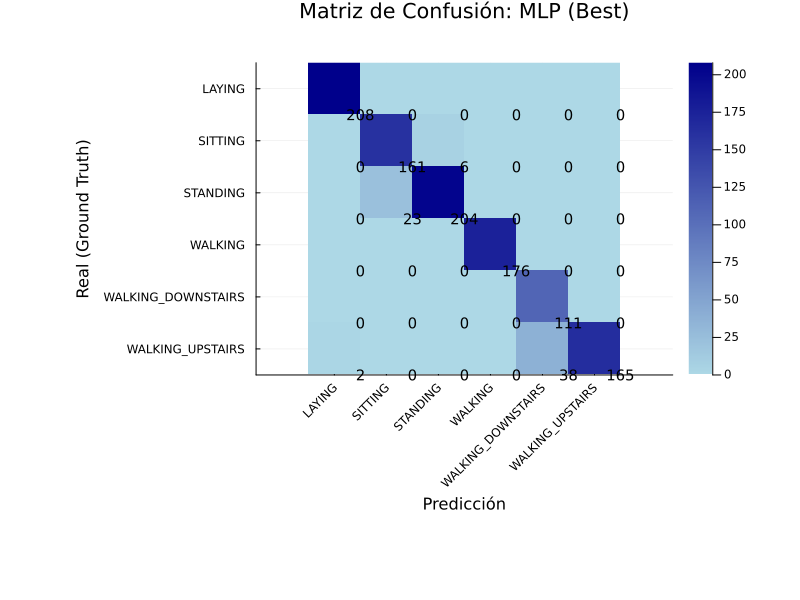

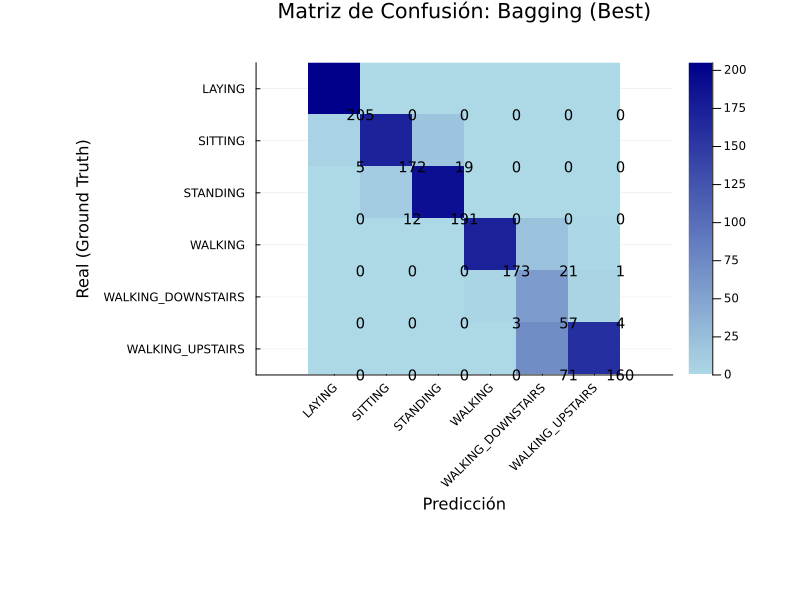

In [30]:
show_cm(dic_matrices_test)

# Modelos de ensemble (Segundo Experimento) usando entrenamiento y validación para entrenar y test para evaluar

In [ ]:
modelos_finales = Dict(
    # Random Forest
    "RandomForest" => RandomForestClassifier(n_trees=500, max_depth=10, rng= Random.MersenneTwister(SEED)),
    
    # Hard Voting
    "HardVoting_Wrapper" => HardVotingClassifier(
        base_model = best_svm, 
        n_partitions = 3, 
        rng = 104
    ),
    
    # Stacking
    "Stacking" => Stack(
        metalearner = NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
        resampling  = CV(nfolds=3),
        model1      = best_svm,
        model2      = best_knn,
        model3      = best_mlp
    ),
    
    # XGBoost
    "XGBoost" => XGBoostClassifier(objective = "multi:softprob", seed=SEED),
    
    # LightGBM
    "LightGBM" => LGBMClassifier(seed=SEED)
);

output_file = "resultados_modelos_ensemble_finales.csv"
output_matrices = "matrices_ensemble_finales.jld2"

dic_matrices_ensembles_finales = Dict()

# Carga de resultados previos del CSV si existen
if isfile(output_file)
    println("Archivo CSV detectado cargando resultados previos")
    existing_results = CSV.read(output_file, DataFrame)
    existing_results.Model = string.(existing_results.Model)
    models_calculated = Set(existing_results.Model)
else
    println("No se encontro CSV previo creando nueva tabla")
    CSV.write(output_file, DataFrame(Model=String[], Accuracy=Float64[], F1=Float64[], B_Accuracy=Float64[]))
    models_calculated = Set{String}()
end

# Carga de matrices previas del JLD2 si existen
if isfile(output_matrices)
    JLD2.@load output_matrices dic_matrices_ensembles_finales
    println("Matrices de confusion previas cargadas")
else
    dic_matrices_ensembles_finales = Dict()
end

println("\nIniciando ejecucion de los 5 Ensembles Finales")

for (nombre, modelo) in modelos_finales
    
    # Checkpoint
    if (nombre in models_calculated) && (haskey(dic_matrices_ensembles_finales, nombre))
        println("Saltando $nombre ya existe en CSV y Diccionario")
        continue
    end

    println("\nProcesando $nombre")
    
    try
        # Entrenamos
        mach = machine(modelo, X_trainval, y_trainval)
        fit!(mach, verbosity=0)
        
        # Predecimos
        y_pred = nothing
        if nombre == "HardVoting_Wrapper"
            println("Usando predict modo determinista")
            y_pred = MLJ.predict(mach, X_test)
        else
            println("Usando predict_mode modo probabilistico")
            y_pred = predict_mode(mach, X_test)
        end
        
        # Metricas
        acc   = accuracy(y_pred, y_test)
        f1    = multiclass_f1score(y_pred, y_test)
        b_acc = balanced_accuracy(y_pred, y_test)
        
        # Guardamos metricas en CSV
        CSV.write(output_file, DataFrame(Model=[nombre], Accuracy=[acc], F1=[f1], B_Accuracy=[b_acc]), append=true)
        
        # Guardamos matriz en diccionario y persistimos en JLD2
        dic_matrices_ensembles_finales[nombre] = confusion_matrix(y_pred, y_test)
        @save output_matrices dic_matrices_ensembles_finales
        
        println("$nombre completado B_Acc $(round(b_acc, digits=4))")
        
    catch e
        println("Error en $nombre $e")
    end
    
    # Liberar memoria
    GC.gc() 
end

println("\nResultados guardados en $output_file")

Archivo CSV detectado cargando resultados previos
Matrices de confusion previas cargadas

Iniciando ejecucion de los 5 Ensembles Finales
Saltando RandomForest ya existe en CSV y Diccionario
Saltando Stacking ya existe en CSV y Diccionario
Saltando HardVoting_Wrapper ya existe en CSV y Diccionario
Saltando XGBoost ya existe en CSV y Diccionario
Saltando LightGBM ya existe en CSV y Diccionario

Resultados guardados en resultados_modelos_ensemble_finales.csv


In [3]:
show_cm(dic_matrices_ensembles_finales)

UndefVarError: UndefVarError: `dic_matrices_ensembles_finales` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Significación de las Variables

In [ ]:
# Definición de los modelos 
rf_model = RandomForestClassifier(n_trees=500, max_depth=10, rng=Random.MersenneTwister(SEED))
xgb_model = XGBoostClassifier(objective = "multi:softprob", seed=SEED)

# Random Forest
println("Entrenando Random Forest...")
mach_rf = machine(rf_model, X_trainval, y_trainval)
fit!(mach_rf, verbosity=0)

# XGBoost
println("Entrenando XGBoost...")
mach_xgb = machine(xgb_model, X_trainval, y_trainval)
fit!(mach_xgb, verbosity=0)

Entrenando Random Forest...
Entrenando XGBoost...


trained Machine; caches model-specific representations of data
  model: XGBoostClassifier(test = 1, …)
  args: 
    1:	Source @867 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @918 ⏎ AbstractVector{Multiclass{6}}


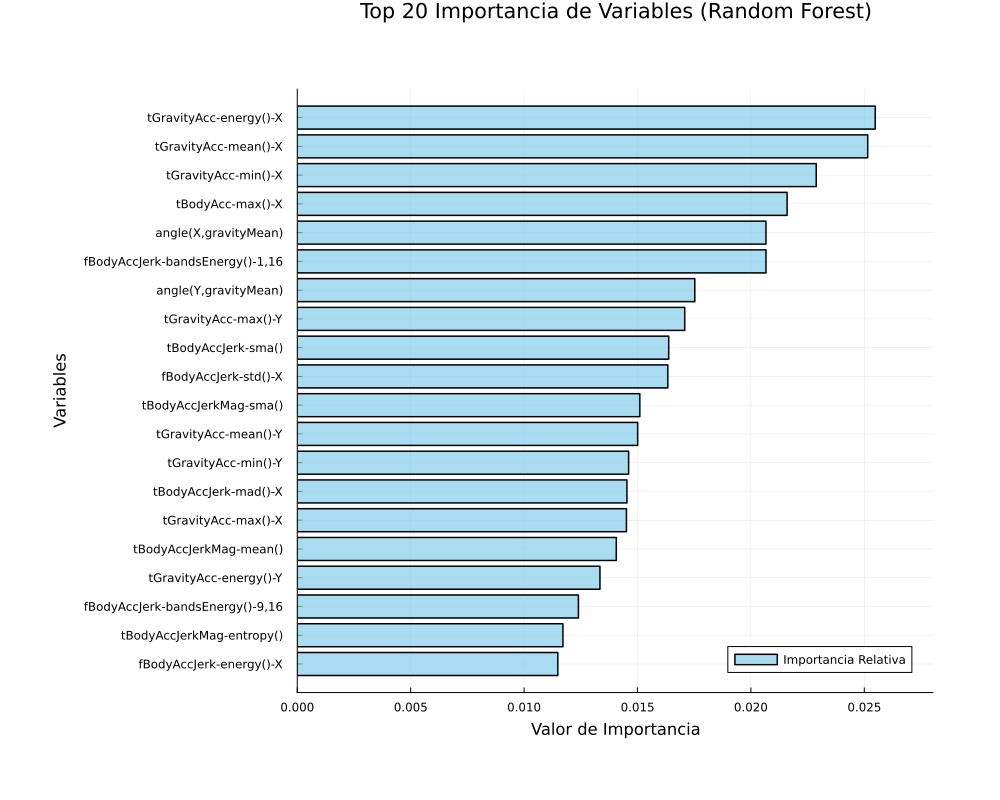

In [ ]:
valores_importantes_rf = feature_importances(mach_rf)
rf_importances = DataFrame(
    feature = [p.first for p in valores_importantes_rf],
    importance = [p.second for p in valores_importantes_rf]
)

rf_importances_20 = reverse(rf_importances[1:20, :]) # Las 20 mejores

bar(
    rf_importances_20.importance,               
    orientation = :horizontal,            
    yticks = (1:20, String.(rf_importances_20.feature)), 
    title = "Top 20 Importancia de Variables (Random Forest)",
    xlabel = "Valor de Importancia",
    ylabel = "Variables",
    label = "Importancia Relativa",
    color = :skyblue,
    fillalpha = 0.7,
    linewidth = 1.5,
    xlims = (0, maximum(rf_importances_20.importance) * 1.1), 
    size = (1000, 800),                   
    margin = 15Plots.mm,                  
    legend = :bottomright
)

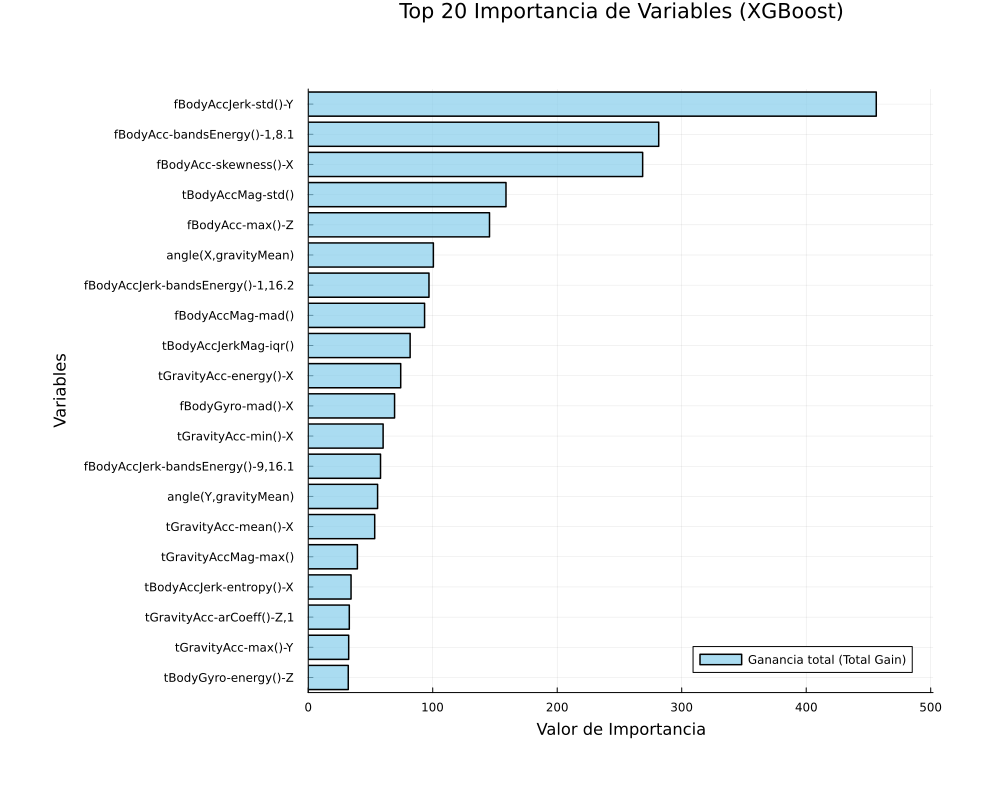

In [ ]:
valores_importantes_xgboost = feature_importances(mach_xgb)
xgb_importances = DataFrame(
    feature = [p.first for p in valores_importantes_xgboost],
    importance = [p.second for p in valores_importantes_xgboost]
)

xgb_importances_20 = reverse(xgb_importances[1:20, :]) # Las 20 mejores

variables = String.(xgb_importances_20.feature)
importancia = xgb_importances_20.importance

bar(
    xgb_importances_20.importance,               
    orientation = :horizontal,            
    ylimits = (0.5, 20.5),
    yticks = (1:20, String.(xgb_importances_20.feature)),
    title = "Top 20 Importancia de Variables (XGBoost)", 
    xlabel = "Valor de Importancia",
    ylabel = "Variables",
    label = "Ganancia total (Total Gain)",
    color = :skyblue,
    fillalpha = 0.7,
    linewidth = 1.5,
    xlims = (0, maximum(xgb_importances_20.importance) * 1.1), 
    size = (1000, 800),                  
    margin = 15Plots.mm,                  
    legend = :bottomright
)

# Test Estadístico

Semilla utilizada: 104
Los folds son idénticos y deterministas.
   Fold 1 Validation indices (primeros 5): [1, 2, 3, 4, 5]
